In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

X = train.drop("target", axis=1).values
y = train["target"].values

X_test = test.values


In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)


In [5]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {0: class_weights[0], 1: class_weights[1]}

print("Class Weights:", class_weights)


Class Weights: {0: np.float64(0.5555555555555556), 1: np.float64(5.0)}


In [6]:
def build_model(input_dim):
    model = models.Sequential([
        layers.Dense(2048,activation='relu', input_dim=input_dim),
        layers.Dropout(0.4),
        
        layers.Dense(1024, activation='relu'),
        layers.Dropout(0.3),
        
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=[]
    )
    return model

model = build_model(X_train.shape[1])
model.summary()


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2048)           │     6,295,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,394,753 (32.02 MB)

 Trainable params: 8,394,753 (32.02 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model = build_model(X_train.shape[1])

model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    class_weight=class_weights,
    verbose=2
)




Epoch 1/10
50/50 - 7s - 134ms/step - loss: 0.9504
Epoch 2/10
50/50 - 4s - 84ms/step - loss: 0.4973
Epoch 3/10
50/50 - 4s - 85ms/step - loss: 0.5142
Epoch 4/10
50/50 - 9s - 175ms/step - loss: 0.3976
Epoch 5/10
50/50 - 4s - 81ms/step - loss: 0.2720
Epoch 6/10
50/50 - 4s - 83ms/step - loss: 0.2988
Epoch 7/10
50/50 - 4s - 79ms/step - loss: 0.2022
Epoch 8/10
50/50 - 4s - 79ms/step - loss: 0.1915
Epoch 9/10
50/50 - 4s - 82ms/step - loss: 0.1556
Epoch 10/10
50/50 - 4s - 84ms/step - loss: 0.1275


In [8]:
pos = y.sum()  #as the classes are 0 and 1..so taking sumation gives how many 1's are there in the dataset (positive samples)
neg = len(y) - pos # tells the no.of 0's in the dataset (negative samples)
scale_pos_weight = neg / pos #ratio important when applying XGboost ..it implies each positive samples get 9 times more weight..it hellps in balancing the classes..and detection of minority classes much easier 
print("Scale Pos Weight =", scale_pos_weight)


Scale Pos Weight = 9.0


In [9]:
y_val_pred=model.predict(X_val).flatten()



13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [11]:
best_bal = 0
best_t = 0

for t in np.arange(0.01, 0.99, 0.01):
    preds = (y_val_pred >=t).astype(int)
    bal = balanced_accuracy_score(y_val, preds)

    if bal > best_bal:
        best_bal = bal
        best_t = t

print("Best Balanced Accuracy:", best_bal)
print("Best threshold:", best_t)

Best Balanced Accuracy: 0.6611111111111111
Best threshold: 0.35000000000000003


In [12]:
X_full = scaler.fit_transform(X)
final_model = build_model(X_full.shape[1])

final_model.fit(
    X_full, y,
    epochs=10,
    batch_size=32,
    class_weight=class_weights,
    verbose=2
)


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
63/63 - 7s - 110ms/step - loss: 0.9785
Epoch 2/10
63/63 - 5s - 83ms/step - loss: 0.5994
Epoch 3/10
63/63 - 5s - 81ms/step - loss: 0.5032
Epoch 4/10
63/63 - 5s - 80ms/step - loss: 0.3701
Epoch 5/10
63/63 - 5s - 82ms/step - loss: 0.3210
Epoch 6/10
63/63 - 6s - 91ms/step - loss: 0.2706
Epoch 7/10
63/63 - 6s - 90ms/step - loss: 0.2329
Epoch 8/10
63/63 - 5s - 82ms/step - loss: 0.2165
Epoch 9/10
63/63 - 5s - 82ms/step - loss: 0.1761
Epoch 10/10
63/63 - 5s - 82ms/step - loss: 0.1505


In [61]:
test_probs = final_model.predict(X_test).flatten()
test_preds = (test_probs >=0.886).astype(int)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [26]:
submission = pd.DataFrame({
    "id":test["id"],
    "target": test_preds
})

submission.to_csv("submission_nueral2.csv", index=False)
print("Saved submission.csv")


Saved submission.csv


In [15]:
y_val.shape

(400,)

In [59]:
val_probs = final_model.predict(X_val).flatten()
val_preds = (val_probs >= 0.886).astype(int)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [56]:
full_probs=final_model.predict(X_full).flatten()
full_preds=(full_probs>=0.886).astype(int)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [63]:
import numpy as np

# y_pred is your prediction array
num_ones = np.sum(test_preds== 0)
print(num_ones)



1816


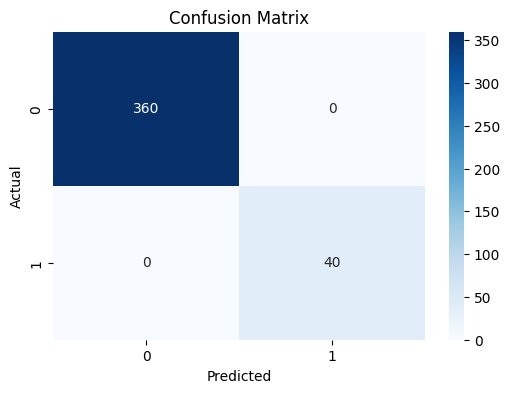

In [60]:
from sklearn.metrics import confusion_matrix

# y_test: true labels
# y_pred: predicted labels (after threshold)
cm = confusion_matrix(y_val, val_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
